# Mini PolyPose: 2D Polyrigid Registration via Log-SE(2)

**Team**
- Rakshit (2310110238)
- Suvrat (2310110317)
- Samarth (2210110531)
- Ishan (2210110307)

## Topic Details

Given sparse 2D observations (one deformed target image), recover a smooth, locally rigid deformation field by:
- Modeling deformation as a blend of rigid transformations
- Using Lie algebra interpolation in log-SE(2)
- Performing differentiable rendering-based optimization
- Avoiding dense displacement fields and heavy regularization

**Core claim:** Constraining deformation to a polyrigid structure improves stability in sparse settings.

## Overall Roadmap

- Phase 0 – Dataset Design and Baseline Setup
- Phase 1 – SE(2) Lie Algebra Implementation
- Phase 2 – Polyrigid Deformation Construction
- Phase 3 – Differentiable Optimization
- Phase 4 – Baseline Comparison
- Phase 5 – Robustness and Ablations
- Phase 6 – Extensions (optional)

## Dataset
Synthetic dataset (controlled, with known ground truth) 

## Phase 0: Synthetic Dataset Creation and Baseline Setup

In this phase we construct a controllable articulated 2D object with known rigid components.

**Why synthetic data here**
- Ground-truth rigid transforms are known
- Segmentation masks are known
- Deformation process is controlled
- Evaluation is unambiguous

**Procedure in the next cells**
1. Define utility imports and random seed
2. Create rigid parts (K = 3 by default)
3. Generate source image, target image, masks, and ground-truth transform parameters

In [1]:
import numpy as np
import cv2
import json
from pathlib import Path
import random
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

# For reproducibility (optional)
random.seed(42)
np.random.seed(42)

In [2]:
def se2_matrix(theta, tx, ty):
    """(theta, tx, ty)  →  3×3 SE(2) matrix."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s, tx],
        [s,  c, ty],
        [0,  0,  1]
    ], dtype=np.float64)

def draw_bone(canvas, mask, occupied, label):
    """Drop a random rectangle onto the canvas without overlaps."""
    h, w = canvas.shape
    for _ in range(50):
        cx = random.randint(50, w - 50)
        cy = random.randint(50, h - 50)
        length = random.randint(60, 100)
        thickness = random.randint(10, 20)
        angle = random.uniform(0, np.pi)

        rect = np.array([
            [-length // 2, -thickness // 2],
            [ length // 2, -thickness // 2],
            [ length // 2,  thickness // 2],
            [-length // 2,  thickness // 2],
        ], dtype=np.float32)
        c, s = np.cos(angle), np.sin(angle)
        R = np.array([[c, -s], [s, c]])
        corners = (rect @ R.T).astype(np.int32)
        corners[:, 0] += cx
        corners[:, 1] += cy

        temp = np.zeros_like(mask)
        cv2.fillPoly(temp, [corners], 255)
        if np.sum((occupied > 0) & (temp > 0)) == 0:
            color = int(120 + label * 30)
            cv2.fillPoly(canvas, [corners], color)
            cv2.fillPoly(mask, [corners], 255)
            occupied[:] = np.maximum(occupied, temp)
            return True
    return False

In [3]:
def generate_sample(image_size=(256, 256), num_parts=3):
    h, w = image_size
    source = np.zeros((h, w), dtype=np.uint8)
    occupied = np.zeros_like(source)
    masks = []
    for i in range(num_parts):
        mask = np.zeros((h, w), dtype=np.uint8)
        draw_bone(source, mask, occupied, i)
        masks.append(mask)

    target = np.zeros_like(source)
    transforms = {}
    for i, mask in enumerate(masks):
        theta = random.uniform(-0.6, 0.6)
        tx    = random.uniform(-25, 25)
        ty    = random.uniform(-25, 25)

        M = np.array([[np.cos(theta), -np.sin(theta), tx],
                      [np.sin(theta),  np.cos(theta), ty]], dtype=np.float32)
        part = cv2.bitwise_and(source, source, mask=mask)
        warped = cv2.warpAffine(part, M, (w, h), flags=cv2.INTER_LINEAR)
        target = np.maximum(target, warped)

        transforms[f"part_{i}"] = {"theta": float(theta),
                                   "tx": float(tx),
                                   "ty": float(ty)}
    return source, target, masks, transforms

## Phase 1: SE(2) Lie Algebra Implementation

We implement SE(2) machinery to ensure mathematically correct rigid transform interpolation.

**Implemented in this phase**
- SE(2) matrix representation
- Exponential map: se(2) -> SE(2)
- Logarithm map: SE(2) -> se(2)
- Numerical stability near rotation angle theta ~ 0

**Verification goal**
- Check `exp(log(T)) ≈ T` to validate correctness

In [4]:
# ============================================================
# Part 2. SE(2) / se(2) — log and exp
# ============================================================
# SE(2) element  T = [ R(θ)  t ; 0 1 ]  (3×3)
# se(2) element  ξ = (ω, vx, vy)
#
#   exp(ξ) = [ R(ω)   V(ω)·v ; 0 1 ]
#                       where v = (vx, vy)
#
#        V(ω) = (1/ω) · [ sin ω     -(1-cos ω) ]
#                       [ 1-cos ω    sin ω     ]      (→ I as ω → 0)
#
#   log(T): ω = atan2(R[1,0], R[0,0]),   v = V(ω)⁻¹ · t
# ============================================================

# %%
def se2_exp(xi):
    """se(2) vector (ω, vx, vy)  →  3×3 SE(2) matrix."""
    omega, vx, vy = xi
    c, s = np.cos(omega), np.sin(omega)
    R = np.array([[c, -s], [s, c]])

    if abs(omega) < 1e-8:
        # V ≈ I + ½ [ω]×  (first-order)
        V = np.eye(2) + 0.5 * np.array([[0.0, -omega],
                                        [omega,  0.0]])
    else:
        V = (1.0 / omega) * np.array([[s,        -(1 - c)],
                                      [1 - c,     s      ]])

    t = V @ np.array([vx, vy])
    T = np.eye(3)
    T[:2, :2] = R
    T[:2,  2] = t
    return T


def se2_log(T):
    """3×3 SE(2) matrix  →  se(2) vector (ω, vx, vy)."""
    R = T[:2, :2]
    t = T[:2,  2]
    omega = np.arctan2(R[1, 0], R[0, 0])

    if abs(omega) < 1e-8:
        V_inv = np.eye(2) - 0.5 * np.array([[0.0, -omega],
                                            [omega,  0.0]])
    else:
        c, s = np.cos(omega), np.sin(omega)
        V = (1.0 / omega) * np.array([[s,        -(1 - c)],
                                      [1 - c,     s      ]])
        V_inv = np.linalg.inv(V)

    v = V_inv @ t
    return np.array([omega, v[0], v[1]])


In [5]:
# Sanity check: exp(log(T)) == T round-trips
T_test = se2_matrix(0.37, 12.3, -4.5)
assert np.allclose(se2_exp(se2_log(T_test)), T_test, atol=1e-10)
print("log/exp roundtrip OK.")

log/exp roundtrip OK.


## Phase 2: Polyrigid Deformation Field Construction

For each pixel x, deformation is modeled as a weighted blend of rigid transforms in log-space.

**Pipeline implemented below**
1. Compute distance-based weights for each rigid segment
2. Normalize weights per pixel
3. Blend transforms in se(2): sum_k w_k(x) log(T_k)
4. Map back via exp to SE(2) and warp pixel coordinates

**Outputs in this phase**
- Weight heatmaps
- Deformation vector fields
- Source vs warped vs target comparison

In [6]:
# ============================================================
# Part 3. PolyPose2D — the polyrigid deformation field
# ============================================================

# %%
class PolyPose2D:
    """
    Builds a dense deformation field Φ : R² → R²  by blending
    per-bone SE(2) transforms in the tangent space se(2).
    """

    def __init__(self, image_size):
        self.H, self.W = image_size
        xs, ys = np.meshgrid(np.arange(self.W), np.arange(self.H))
        # grid stores the (x=col, y=row) coordinate of each pixel
        self.grid_x = xs.astype(np.float64)   # (H, W)
        self.grid_y = ys.astype(np.float64)   # (H, W)

    # --------------------------------------------------------
    # Weight field — PolyPose Eq. (6)
    #     w_k(x) = m_k / (1 + d_k(x)²)
    # where  d_k(x) = Euclidean distance from x to mask S_k
    # and    m_k    = normalized mass (= area of S_k)
    # --------------------------------------------------------
    def compute_weights(self, masks):
        K = len(masks)
        dists  = np.zeros((K, self.H, self.W))
        masses = np.zeros(K)

        for k, mask in enumerate(masks):
            # distance_transform_edt: for each pixel, distance to the
            # nearest 0-valued pixel. Pass (mask == 0) so that distance
            # is measured from points outside the mask to the mask.
            dists[k]  = distance_transform_edt(mask == 0)
            masses[k] = float(mask.sum())

        masses /= masses.sum()                         # normalize mass
        W  = masses[:, None, None] / (1.0 + dists ** 2)
        W /= (W.sum(axis=0, keepdims=True) + 1e-12)    # Σ_k w_k(x) = 1
        return W

    # --------------------------------------------------------
    # Polyrigid deformation field (VECTORIZED)
    #
    #   Given K rigid transforms T_1,…,T_K and weights W:
    #
    #     ξ(x)  = Σ_k  W[k,x] · log(T_k)           ∈ se(2)
    #     T(x)  = exp(ξ(x))                        ∈ SE(2)
    #     Φ(x)  = T(x) · x̃
    #
    # Implemented as pixel-wise exp, fully vectorized over (H, W).
    # --------------------------------------------------------
    def compute_deformation_field(self, log_poses, W):
        """
        log_poses : (K, 3) stack of [ω, vx, vy]  =  log(T_k)
        W         : (K, H, W) normalized weight field
        returns Φ : (H, W, 2) where Φ[i, j] = image of pixel (x=j, y=i)
        """
        # Blend in se(2):  ξ_field[i, j, d] = Σ_k W[k,i,j] * log_poses[k,d]
        xi_field = np.einsum('khw,kd->hwd', W, log_poses)   # (H, W, 3)
        omega = xi_field[..., 0]           # (H, W)
        vx    = xi_field[..., 1]           # (H, W)
        vy    = xi_field[..., 2]           # (H, W)

        # Pixel-wise exp — build R(ω) and V(ω) everywhere at once
        c, s = np.cos(omega), np.sin(omega)
        small = np.abs(omega) < 1e-8
        safe_w = np.where(small, 1.0, omega)              # avoid /0

        V00 = np.where(small,  1.0,           s / safe_w)
        V01 = np.where(small, -0.5 * omega,  -(1 - c) / safe_w)
        V10 = np.where(small,  0.5 * omega,   (1 - c) / safe_w)
        V11 = np.where(small,  1.0,           s / safe_w)

        tx = V00 * vx + V01 * vy
        ty = V10 * vx + V11 * vy

        # Apply T(x) to each pixel: [ R(ω)  t ] · [x, y, 1]
        phi_x = c * self.grid_x - s * self.grid_y + tx
        phi_y = s * self.grid_x + c * self.grid_y + ty
        return np.stack([phi_x, phi_y], axis=-1)          # (H, W, 2)

In [7]:
# ============================================================
# Part 4. Warping  —  numerical inverse by fixed-point iteration
# ============================================================
# Φ is a forward field:  Φ(x) tells us where source pixel x goes.
# For cv2.remap we need the INVERSE:
#     for each target pixel y, which source pixel landed here?
# i.e. find x such that Φ(x) = y.
#
# Because Φ is a diffeomorphism, the fixed-point iteration
#     x_{n+1} = x_n − (Φ(x_n) − y)
# converges quickly from x_0 = y.
# ============================================================

# %%
def invert_field(phi, n_iter=20):
    """phi : (H, W, 2)  forward field  →  inverse field, same shape."""
    H, W = phi.shape[:2]
    phi_x = phi[..., 0].astype(np.float32)
    phi_y = phi[..., 1].astype(np.float32)

    tgt_x, tgt_y = np.meshgrid(np.arange(W, dtype=np.float32),
                               np.arange(H, dtype=np.float32))
    inv_x = tgt_x.copy()
    inv_y = tgt_y.copy()
    for _ in range(n_iter):
        # evaluate Φ at current guess (inv_x, inv_y)
        phi_ax = cv2.remap(phi_x, inv_x, inv_y,
                           interpolation=cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_REPLICATE)
        phi_ay = cv2.remap(phi_y, inv_x, inv_y,
                           interpolation=cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_REPLICATE)
        inv_x -= (phi_ax - tgt_x)
        inv_y -= (phi_ay - tgt_y)

    return np.stack([inv_x, inv_y], axis=-1)


def warp_image(source, inverse_field):
    mx = inverse_field[..., 0].astype(np.float32)
    my = inverse_field[..., 1].astype(np.float32)
    return cv2.remap(source, mx, my,
                     interpolation=cv2.INTER_LINEAR,
                     borderMode=cv2.BORDER_CONSTANT)

In [8]:
# ============================================================
# Part 5. End-to-end pipeline
# ============================================================

# %%
source, target, masks, transforms = generate_sample()

# (A) Build log(T_k) for each part -------------------------------
log_poses = []
for key in sorted(transforms.keys()):
    t = transforms[key]
    T_k = se2_matrix(t["theta"], t["tx"], t["ty"])
    log_poses.append(se2_log(T_k))
log_poses = np.array(log_poses)                 # (K, 3)

print("log(T_k) for each part:")
for k, xi in enumerate(log_poses):
    print(f"  part_{k}: ω={xi[0]:+.3f},  vx={xi[1]:+.3f},  vy={xi[2]:+.3f}")

# (B) Weight field (Eq. 6) ---------------------------------------
pp = PolyPose2D(image_size=source.shape)
W  = pp.compute_weights(masks)

# (C) Polyrigid deformation field --------------------------------
phi = pp.compute_deformation_field(log_poses, W)

# (D) Warp source image ------------------------------------------
phi_inv = invert_field(phi, n_iter=20)
warped  = warp_image(source, phi_inv)

log(T_k) for each part:
  part_0: ω=+0.443,  vx=+8.957,  vy=-19.605
  part_1: ω=-0.093,  vx=-10.438,  vy=-14.740
  part_2: ω=+0.316,  vx=-20.673,  vy=-2.809


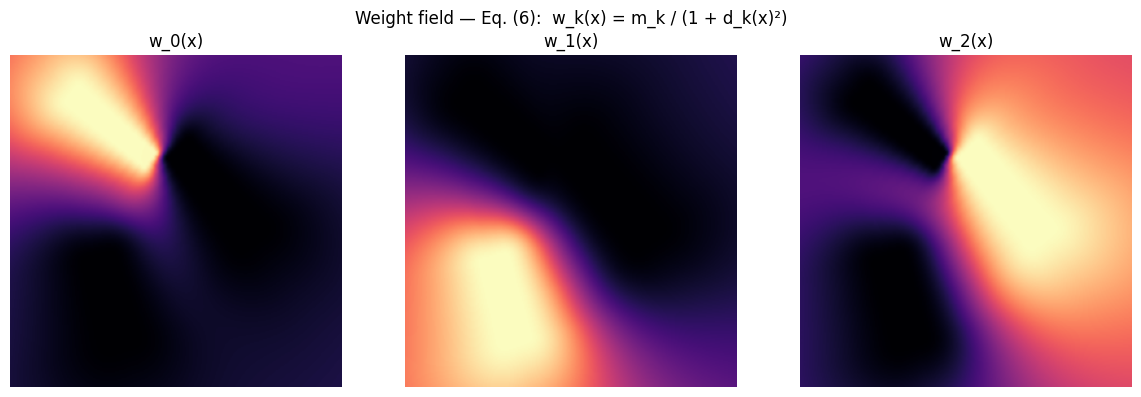

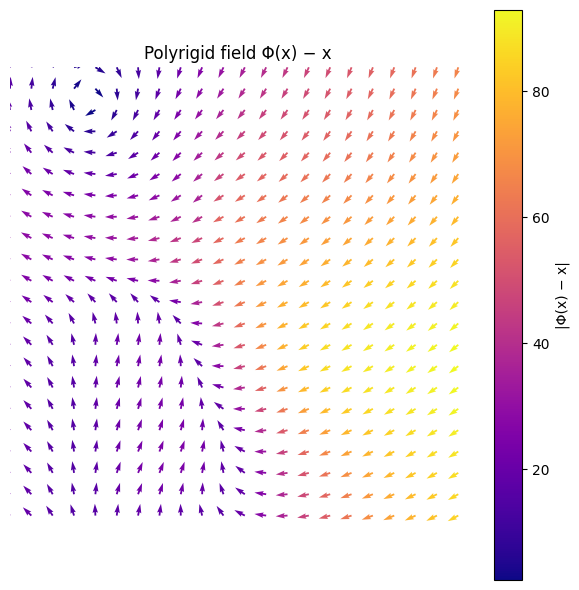

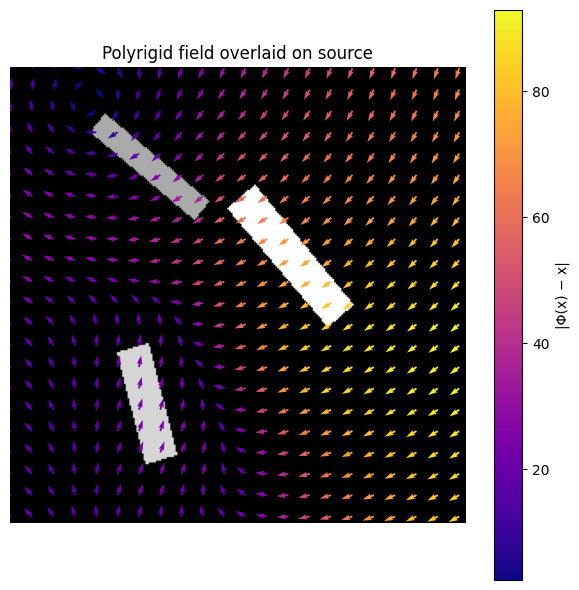

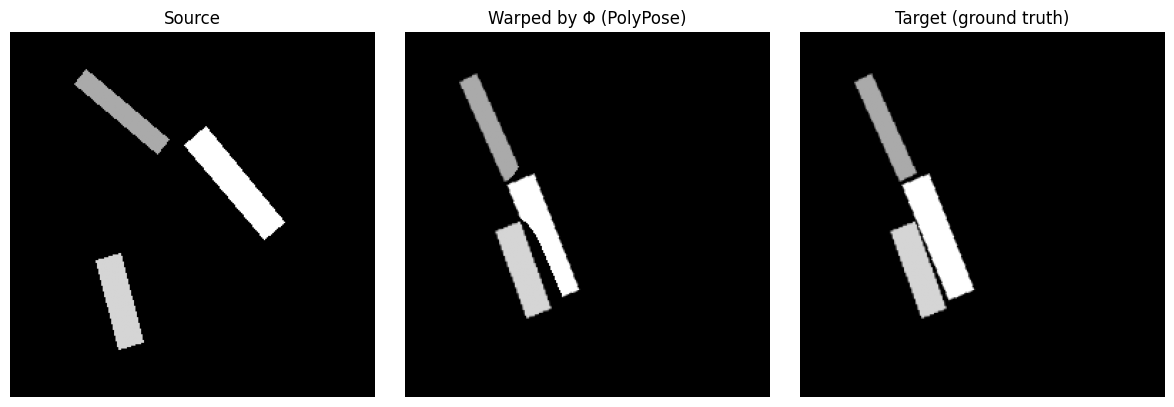

In [9]:
# ============================================================
# Part 6. Visualizations
# ============================================================

# %%
def plot_field(phi, background=None, step=12, title="Deformation field"):
    H, W = phi.shape[:2]
    Xs, Ys = np.meshgrid(np.arange(W), np.arange(H))
    dx = phi[..., 0] - Xs
    dy = phi[..., 1] - Ys
    mag = np.sqrt(dx ** 2 + dy ** 2) + 1e-8

    fig, ax = plt.subplots(figsize=(6, 6))
    if background is not None:
        ax.imshow(background, cmap='gray')
    else:
        ax.set_xlim(0, W); ax.set_ylim(H, 0)

    q = ax.quiver(Xs[::step, ::step], Ys[::step, ::step],
                  (dx / mag)[::step, ::step],
                  (dy / mag)[::step, ::step],        # y already points down
                  mag[::step, ::step],
                  angles='xy', scale_units='xy', scale=0.15,
                  cmap='plasma', width=0.004)
    plt.colorbar(q, ax=ax, label='|Φ(x) − x|')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# (1) weight field (relative part contribution per pixel)
plt.figure(figsize=(4 * len(masks), 4))
for k in range(len(masks)):
    plt.subplot(1, len(masks), k + 1)
    plt.imshow(W[k], cmap='magma', vmin=0, vmax=1)
    plt.title(f"w_{k}(x)")
    plt.axis('off')
plt.suptitle("Weight field — Eq. (6):  w_k(x) = m_k / (1 + d_k(x)²)")
plt.tight_layout(); plt.show()

# (2) raw polyrigid field
plot_field(phi, step=12, title="Polyrigid field Φ(x) − x")

# (3) overlaid on source
plot_field(phi, background=source, step=12,
           title="Polyrigid field overlaid on source")

# (4) source vs warped vs target
plt.figure(figsize=(12, 4))
for i, (img, ttl) in enumerate([(source, "Source"),
                                (warped, "Warped by Φ (PolyPose)"),
                                (target, "Target (ground truth)")]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray'); plt.title(ttl); plt.axis('off')
plt.tight_layout(); plt.show()

## Phase 3: Differentiable Optimization

Goal: recover unknown rigid parameters from only the deformed target image.

**Optimization loop in the next cells**
1. Initialize SE(2) parameters
2. Build differentiable polyrigid warp in PyTorch
3. Render warped source
4. Compute similarity loss (NCC / mNCC / optional gmNCC variant if enabled)
5. Backpropagate through log/exp blending and warping
6. Optimize parameters with Adam

**Primary diagnostics**
- Convergence curve
- Parameter error against ground truth
- Visual alignment overlays

In [10]:
# ============================================================
#  PolyPose 2D — TRAINING (inverse problem)
#
#  Paste these cells into your notebook AFTER Part 6.
#  Each `# %%` marker is a separate Colab cell.
#
#  PREREQUISITES from earlier cells (must already be defined):
#    - source, target, masks, transforms    (from generate_sample)
#    - se2_matrix, se2_exp, se2_log         (Part 2)
#    - PolyPose2D  ← the CORRECT one from Part 3
#                   (make sure you deleted the duplicate!)
# ============================================================


# %% ----------  CELL A: imports  ----------
import torch
import torch.nn.functional as F
from scipy.ndimage import distance_transform_edt

In [11]:
# %% ----------  CELL B: PyTorch version of the polyrigid forward model ----------
#
# Exactly the same math as Part 3's NumPy PolyPose2D, but every op
# is differentiable, so autograd can flow gradients all the way from
# the image loss back to the se(2) parameters.
#
class PolyPose2D_Torch:
    """Differentiable polyrigid forward model in SE(2)."""

    def __init__(self, image_size, device='cpu'):
        self.H, self.W = image_size
        self.device = device

        xs, ys = torch.meshgrid(
            torch.arange(self.W, device=device, dtype=torch.float32),
            torch.arange(self.H, device=device, dtype=torch.float32),
            indexing='xy'
        )
        self.grid_x = xs          # (H, W), grid_x[i, j] = j   (column)
        self.grid_y = ys          # (H, W), grid_y[i, j] = i   (row)

    # ------------------------------------------------------------------
    # Φ(x) = exp( Σ_k w_k(x)·log(T_k) ) · x̃         — vectorized
    # ------------------------------------------------------------------
    def compute_deformation_field(self, log_poses, W):
        """
        log_poses : (K, 3)    [ω, vx, vy]   — can require_grad
        W         : (K, H, W) normalized weight field
        returns     (H, W, 2) forward field
        """
        xi = torch.einsum('khw,kd->hwd', W, log_poses)      # (H, W, 3)
        omega, vx, vy = xi[..., 0], xi[..., 1], xi[..., 2]

        c = torch.cos(omega); s = torch.sin(omega)

        # pixel-wise V(ω) (first-order fallback for ω ≈ 0)
        small  = omega.abs() < 1e-6
        w_safe = torch.where(small, torch.ones_like(omega), omega)

        V00 = torch.where(small, torch.ones_like(omega),  s / w_safe)
        V01 = torch.where(small, -0.5 * omega,         -(1 - c) / w_safe)
        V10 = torch.where(small,  0.5 * omega,          (1 - c) / w_safe)
        V11 = torch.where(small, torch.ones_like(omega),  s / w_safe)

        tx = V00 * vx + V01 * vy
        ty = V10 * vx + V11 * vy

        phi_x = c * self.grid_x - s * self.grid_y + tx
        phi_y = s * self.grid_x + c * self.grid_y + ty
        return torch.stack([phi_x, phi_y], dim=-1)          # (H, W, 2)

    # ------------------------------------------------------------------
    # Differentiable fixed-point inverse of Φ
    # ------------------------------------------------------------------
    @staticmethod
    def invert_field(phi, n_iter=10):
        H, W = phi.shape[:2]
        device, dtype = phi.device, phi.dtype

        tgt_x, tgt_y = torch.meshgrid(
            torch.arange(W, device=device, dtype=dtype),
            torch.arange(H, device=device, dtype=dtype),
            indexing='xy'
        )
        inv_x, inv_y = tgt_x.clone(), tgt_y.clone()
        phi_stack = phi.permute(2, 0, 1).unsqueeze(0)       # (1, 2, H, W)

        for _ in range(n_iter):
            grid = torch.stack([
                2.0 * inv_x / (W - 1) - 1.0,
                2.0 * inv_y / (H - 1) - 1.0
            ], dim=-1).unsqueeze(0)                         # (1, H, W, 2)

            sampled = F.grid_sample(
                phi_stack, grid,
                mode='bilinear', padding_mode='border',
                align_corners=True
            ).squeeze(0)                                    # (2, H, W)

            inv_x = inv_x - (sampled[0] - tgt_x)
            inv_y = inv_y - (sampled[1] - tgt_y)

        return torch.stack([inv_x, inv_y], dim=-1)

    # ------------------------------------------------------------------
    # Differentiable image warp (cv2.remap equivalent)
    # ------------------------------------------------------------------
    @staticmethod
    def warp_image(source, inverse_field):
        H, W = source.shape
        grid = torch.stack([
            2.0 * inverse_field[..., 0] / (W - 1) - 1.0,
            2.0 * inverse_field[..., 1] / (H - 1) - 1.0
        ], dim=-1).unsqueeze(0)
        warped = F.grid_sample(
            source.unsqueeze(0).unsqueeze(0), grid,
            mode='bilinear', padding_mode='zeros', align_corners=True
        )
        return warped.squeeze()


In [12]:
# %% ----------  CELL C: the Trainer  ----------
#
# Optimizes ξ_k = log(T_k) ∈ se(2)  so that warp(source, Φ[ξ]) ≈ target.
#
#   Parameters: ω_k  (rotation, rad)   and  v_k = (vx, vy)  (translation, px)
#   Optimizer:  Adam   with DIFFERENT learning rates for ω vs v
#               (because rotations are ~0.1 rad, translations ~10-100 px)
#   Losses:     'mncc' (multi-scale NCC, closer to the paper)
#
class PolyPoseTrainer:

    def __init__(self, source, target, masks,
                 lr_rotation=1e-2,
                 lr_translation=1.0,
                 device=None,
                 n_invert_iter=10):

        if device is None:
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.device  = device
        self.loss_type = 'mncc'
        self.n_invert_iter = n_invert_iter
        self.lr_rotation    = lr_rotation
        self.lr_translation = lr_translation

        # --- images (normalized to [0, 1]) ---
        self.source = torch.from_numpy(
            source.astype(np.float32) / 255.0).to(device)
        self.target = torch.from_numpy(
            target.astype(np.float32) / 255.0).to(device)

        # --- weight field  (fixed, precomputed)  — Eq. (6) ---
        self.W = torch.from_numpy(
            self._compute_weights(masks)).float().to(device)

        # --- polyrigid forward model ---
        self.model = PolyPose2D_Torch(source.shape, device=device)

        # --- LEARNABLE parameters, in two groups with different lrs ---
        K = len(masks)
        self.omega = torch.nn.Parameter(               # rotations  (K,)
            torch.zeros(K, device=device))
        self.v     = torch.nn.Parameter(               # translations (K, 2)
            torch.zeros(K, 2, device=device))

        self.optimizer = torch.optim.Adam([
            {'params': [self.omega], 'lr': lr_rotation},
            {'params': [self.v],     'lr': lr_translation},
        ])

        self.history = {'loss': [], 'params': []}

    # ------------------------------------------------------------------
    # Weight field (Eq. 6):  w_k(x) = m_k / (1 + d_k(x)²),  Σ_k w_k = 1
    # ------------------------------------------------------------------
    @staticmethod
    def _compute_weights(masks):
        K = len(masks)
        H, W = masks[0].shape
        dists  = np.zeros((K, H, W))
        masses = np.zeros(K)
        for k, m in enumerate(masks):
            dists[k]  = distance_transform_edt(m == 0)
            masses[k] = float(m.sum())
        masses /= masses.sum()
        Wf  = masses[:, None, None] / (1.0 + dists ** 2)
        Wf /= (Wf.sum(axis=0, keepdims=True) + 1e-12)
        return Wf

    # ------------------------------------------------------------------
    # Losses
    # ------------------------------------------------------------------
    @staticmethod
    def _ncc(A, B):
        """Global normalized cross correlation, returned NEGATED (minimized)."""
        A = A.flatten(); B = B.flatten()
        A = A - A.mean(); B = B - B.mean()
        num = (A * B).sum()
        den = torch.sqrt((A * A).sum() * (B * B).sum() + 1e-8)
        return -(num / den)                        # minimize -NCC → maximize NCC

    @classmethod
    def _mncc(cls, A, B, scales=(1, 2, 4)):
        """Multi-scale NCC — averaged over progressively downsampled images.
           This is a simplified version of the paper's gmNCC (Sec. 3.4).  """
        A4 = A.unsqueeze(0).unsqueeze(0)
        B4 = B.unsqueeze(0).unsqueeze(0)
        loss = 0.0
        for s in scales:
            As = A if s == 1 else F.avg_pool2d(A4, s).squeeze()
            Bs = B if s == 1 else F.avg_pool2d(B4, s).squeeze()
            loss = loss + cls._ncc(As, Bs)
        return loss / len(scales)

    def compute_loss(self, warped):
        """Global mNCC + per-part local NCC (weight=0.3).

        When global NCC saturates after two parts align, gradients for the
        still-misaligned part drop near zero.  The local term keeps per-part
        gradient alive throughout training.
        """
        global_loss = self._mncc(warped, self.target)

        local_loss = torch.tensor(0.0, device=self.device)
        n_valid = 0
        for W_k in self.W:
            mask = W_k > 0.5
            if mask.sum() > 100:
                local_loss = local_loss + self._ncc(warped[mask], self.target[mask])
                n_valid += 1

        if n_valid > 0:
            local_loss = local_loss / n_valid
            return global_loss + 0.3 * local_loss

        return global_loss

    # ------------------------------------------------------------------
    # Forward pass
    # ------------------------------------------------------------------
    def forward(self):
        params = torch.cat([self.omega.unsqueeze(-1), self.v], dim=-1)  # (K,3)
        phi     = self.model.compute_deformation_field(params, self.W)
        phi_inv = self.model.invert_field(phi, n_iter=self.n_invert_iter)
        warped  = self.model.warp_image(self.source, phi_inv)
        return warped, phi

    # ------------------------------------------------------------------
    # Training loop
    # ------------------------------------------------------------------
    def train(self, n_iter=300, print_every=25):
        print(f"Training:  loss={self.loss_type.upper()}   "
              f"device={self.device}   iters={n_iter}")

        for it in range(n_iter):
            self.optimizer.zero_grad()
            warped, _ = self.forward()
            loss = self.compute_loss(warped)
            loss.backward()
            self.optimizer.step()

            self.history['loss'].append(loss.item())
            self.history['params'].append(self._snapshot_params())

            if it == 0 or (it + 1) % print_every == 0:
                print(f"  iter {it+1:4d}/{n_iter}   loss = {loss.item():+.6f}")

        with torch.no_grad():
            warped, phi = self.forward()
        print(f"\nFinal ξ_k (ω, vx, vy):\n{self._snapshot_params()}")
        return (warped.detach().cpu().numpy(),
                phi.detach().cpu().numpy())

    def _snapshot_params(self):
        return np.concatenate([
            self.omega.detach().cpu().numpy()[:, None],
            self.v.detach().cpu().numpy()
        ], axis=1)

    # ------------------------------------------------------------------
    # Convert learned (ω, v) → (theta, tx, ty) for comparison with the GT
    # ------------------------------------------------------------------
    def get_learned_transforms(self):
        xi = self._snapshot_params()
        out = []
        for k in range(xi.shape[0]):
            T = se2_exp(xi[k])                      # from Part 2
            out.append({'theta': float(xi[k, 0]),
                        'tx':    float(T[0, 2]),
                        'ty':    float(T[1, 2])})
        return out


In [13]:
# %% ----------  CELL D: visualization helpers  ----------
def plot_loss(history, title):
    plt.figure(figsize=(8, 3.5))
    plt.plot(history['loss'], lw=2)
    plt.xlabel('iteration'); plt.ylabel('loss'); plt.title(title)
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


def plot_warp_triplet(source, warped, target, suffix=''):
    warped_u8 = (warped * 255).clip(0, 255)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, img, ttl in zip(axes,
                            [source, warped_u8, target],
                            ['Source', f'Warped (learned){suffix}', 'Target']):
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(ttl); ax.axis('off')
    plt.tight_layout(); plt.show()


def plot_overlay(source, warped, target, suffix=''):
    warped_u8 = (warped * 255).clip(0, 255)
    before = np.zeros((*source.shape, 3), dtype=np.float32)
    before[..., 0] = target / 255.0          # target  = red
    before[..., 1] = source / 255.0          # source  = green
    after = np.zeros_like(before)
    after[..., 0] = target / 255.0
    after[..., 1] = warped_u8 / 255.0

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(before)
    ax[0].set_title('Before: source (green) vs target (red)')
    ax[1].imshow(after)
    ax[1].set_title(f'After: warped (green) vs target (red){suffix}')
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()


def compare_params(learned, ground_truth):
    print('=' * 64)
    print(f'{"part":<6}{"param":<8}{"learned":>14}{"true":>14}{"|err|":>14}')
    print('-' * 64)
    total, n = 0.0, 0
    for k, lr in enumerate(learned):
        gt = ground_truth[f'part_{k}']
        for p in ('theta', 'tx', 'ty'):
            err = abs(lr[p] - gt[p])
            print(f'p_{k}   {p:<8}{lr[p]:>14.4f}{gt[p]:>14.4f}{err:>14.4f}')
            total += err; n += 1
    print('-' * 64)
    print(f'MAE over all {n} params: {total/n:.4f}')
    print('=' * 64)

In [14]:
# ============================================================
#  PolyPose 2D — FIXES for bad convergence
#
#  Append these cells to your notebook AFTER the previous
#  polypose_training.py cells.
#
#  Adds a new method to your existing PolyPoseTrainer:
#      1. train_multiscale()    — coarse-to-fine via Gaussian blur
# ============================================================


# %% ----------  CELL I: extra imports  ----------
from torchvision.transforms.functional import gaussian_blur as _gblur_torch
from scipy.optimize import linear_sum_assignment


In [15]:
def _blur(img, sigma):
    """Gaussian blur a (H, W) tensor, or return unchanged if sigma ≤ 0."""
    if sigma <= 0.1:
        return img
    ks = 2 * int(3 * sigma) + 1
    img4 = img.unsqueeze(0).unsqueeze(0)
    out  = _gblur_torch(img4, kernel_size=[ks, ks], sigma=[sigma, sigma])
    return out.squeeze()


def train_multiscale(self,
                     schedule=((200, 8.0),
                               (200, 4.0),
                               (300, 2.0),
                               (400, 0.5)),
                     print_every=50):
    """
    Coarse-to-fine training. Each (n_iter, sigma) pair is a stage.

    Higher sigma ⇒ more blur ⇒ bones become big soft blobs
                 ⇒ gradient propagates over LONG distances
                 ⇒ escapes the local-minimum trap of sharp-image NCC.

    Progressively reduce sigma to refine to pixel accuracy.
    Optimizer is reset at each stage to clear stale Adam momentum
    (m, v buffers built at σ=8 are harmful at σ=0.5).
    """
    # cache originals so we can restore at the end
    orig_source = self.source
    orig_target = self.target

    print(f"Multi-scale training   loss={self.loss_type.upper()}   device={self.device}")
    print(f"Schedule (iters, sigma):  {list(schedule)}\n")

    it_total = 0
    for stage, (n_iter, sigma) in enumerate(schedule):
        # Reset optimizer at each stage — clears stale Adam m/v buffers.
        # Decay LR as we refine: coarser stages need larger steps to escape
        # wide basins; fine stages need smaller steps for sub-pixel precision.
        lr_scale = 0.5 ** stage
        self.optimizer = torch.optim.Adam([
            {'params': [self.omega], 'lr': self.lr_rotation    * lr_scale},
            {'params': [self.v],     'lr': self.lr_translation * lr_scale},
        ])

        print(f"── stage {stage+1}/{len(schedule)}:  σ = {sigma:4.1f},  "
              f"{n_iter} iters  "
              f"lr_rot={self.lr_rotation*lr_scale:.4f}  "
              f"lr_trans={self.lr_translation*lr_scale:.3f}"
              + ("  (finest)" if sigma <= 0.5 else ""))

        # blur both images at this resolution
        self.source = _blur(orig_source, sigma)
        self.target = _blur(orig_target, sigma)

        for _ in range(n_iter):
            self.optimizer.zero_grad()
            warped, _ = self.forward()
            loss = self.compute_loss(warped)
            loss.backward()
            self.optimizer.step()

            self.history['loss'].append(loss.item())
            self.history['params'].append(self._snapshot_params())

            it_total += 1
            if it_total == 1 or it_total % print_every == 0:
                print(f"    iter {it_total:4d}  σ={sigma:4.1f}   loss = {loss.item():+.6f}")

    # restore original sharp images
    self.source = orig_source
    self.target = orig_target

    # one final sharp-image forward pass for the returned output
    with torch.no_grad():
        warped, phi = self.forward()
    print(f"\nfinal ξ_k:\n{self._snapshot_params()}")
    return warped.detach().cpu().numpy(), phi.detach().cpu().numpy()


# attach the new methods to the existing class
PolyPoseTrainer.train_multiscale = train_multiscale
print("PolyPoseTrainer patched with .train_multiscale()")


PolyPoseTrainer patched with .train_multiscale()


## Phase 4: Baseline Comparison

This phase compares the polyrigid model against simpler or less constrained alternatives.

**Planned baselines**
- Dense displacement field registration
- Affine-only registration
- Single rigid transform

**Current notebook status**
- Runs the main PolyPose training experiment (NCC + multi-scale).
- Produces quantitative parameter error and qualitative alignment plots.

**Recommended metrics to report**
- Pixel MSE
- SSIM
- Deformation smoothness
- Jacobian sign consistency / folding checks (if dense baseline is added)

In [16]:
# %% ---------- experiment - NCC with MULTI-SCALE  ----------
print("\n" + "#" * 66)
print("#   EXPERIMENT — NCC + multi-scale")
print("#" * 66)

trainer_ncc_ms = PolyPoseTrainer(
    source, target, masks,
    lr_rotation=1e-2,
    lr_translation=1.0,
)
warped_ncc_ms, phi_trained = trainer_ncc_ms.train_multiscale(
    schedule=[(200, 8.0), (200, 4.0), (300, 2.0), (400, 0.5)],
    print_every=100,
)

learned_ncc_ms = trainer_ncc_ms.get_learned_transforms()



##################################################################
#   EXPERIMENT — NCC + multi-scale
##################################################################
Multi-scale training   loss=MNCC   device=cpu
Schedule (iters, sigma):  [(200, 8.0), (200, 4.0), (300, 2.0), (400, 0.5)]

── stage 1/4:  σ =  8.0,  200 iters  lr_rot=0.0100  lr_trans=1.000
    iter    1  σ= 8.0   loss = -0.096546
    iter  100  σ= 8.0   loss = -1.226393
    iter  200  σ= 8.0   loss = -1.249153
── stage 2/4:  σ =  4.0,  200 iters  lr_rot=0.0050  lr_trans=0.500
    iter  300  σ= 4.0   loss = -1.226429
    iter  400  σ= 4.0   loss = -1.226116
── stage 3/4:  σ =  2.0,  300 iters  lr_rot=0.0025  lr_trans=0.250
    iter  500  σ= 2.0   loss = -1.131137
    iter  600  σ= 2.0   loss = -1.132366
    iter  700  σ= 2.0   loss = -1.132496
── stage 4/4:  σ =  0.5,  400 iters  lr_rot=0.0013  lr_trans=0.125  (finest)
    iter  800  σ= 0.5   loss = -1.128108
    iter  900  σ= 0.5   loss = -1.126181
    iter 1000  σ= 0.

part  param          learned          true         |err|
----------------------------------------------------------------
p_0   theta           0.4504        0.4432        0.0073
p_0   tx             13.5061       12.9404        0.5657
p_0   ty            -17.2158      -17.0170        0.1988
p_1   theta          -0.0942       -0.0929        0.0013
p_1   tx            -11.5135      -11.1064        0.4071
p_1   ty            -13.7165      -14.2343        0.5178
p_2   theta           0.3202        0.3162        0.0040
p_2   tx            -19.3461      -19.8895        0.5434
p_2   ty             -6.3152       -6.0036        0.3116
----------------------------------------------------------------
MAE over all 9 params: 0.2841


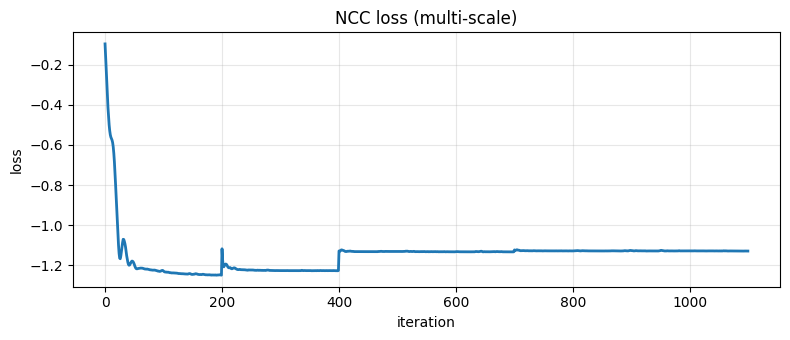

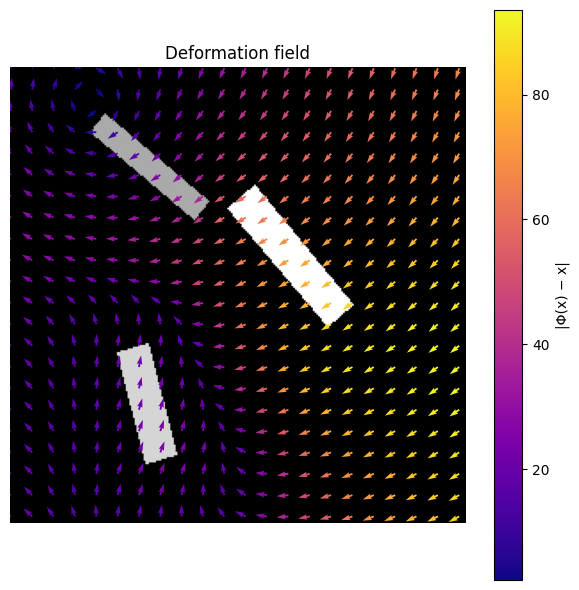

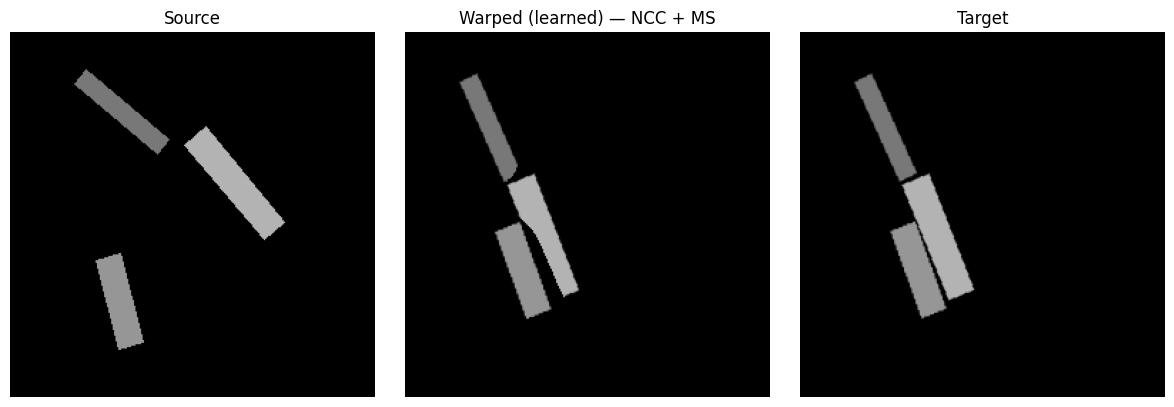

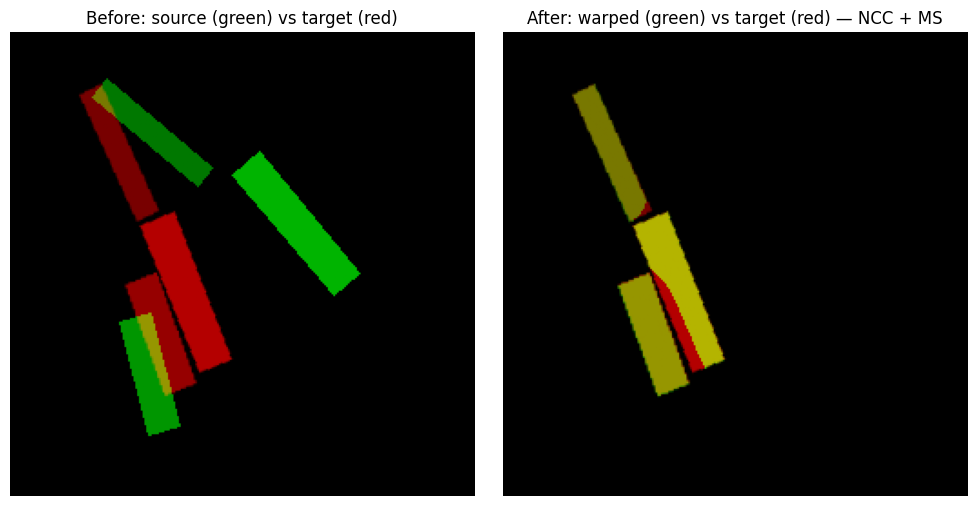

In [17]:
compare_params(learned_ncc_ms, transforms)

plot_loss(trainer_ncc_ms.history, 'NCC loss (multi-scale)')
plot_field(phi_trained, source)
plot_warp_triplet(source, warped_ncc_ms, target, suffix=' — NCC + MS')
plot_overlay(source, warped_ncc_ms, target, suffix=' — NCC + MS')

Method                              MSE       SSIM       Smooth      Fold%    mean detJ
-----------------------------------------------------------------------------------------------
PolyPose (NCC+MS)               0.00273     0.9276       7.9437      0.012      16.0676
Single rigid (ECC)              0.03064     0.2914       1.4142      0.000       1.0000
Affine (ECC)                    0.02867     0.2621       1.2787      0.000       0.7949
Dense flow (Farneback)          0.04204     0.0414       1.4142      0.000       1.0000


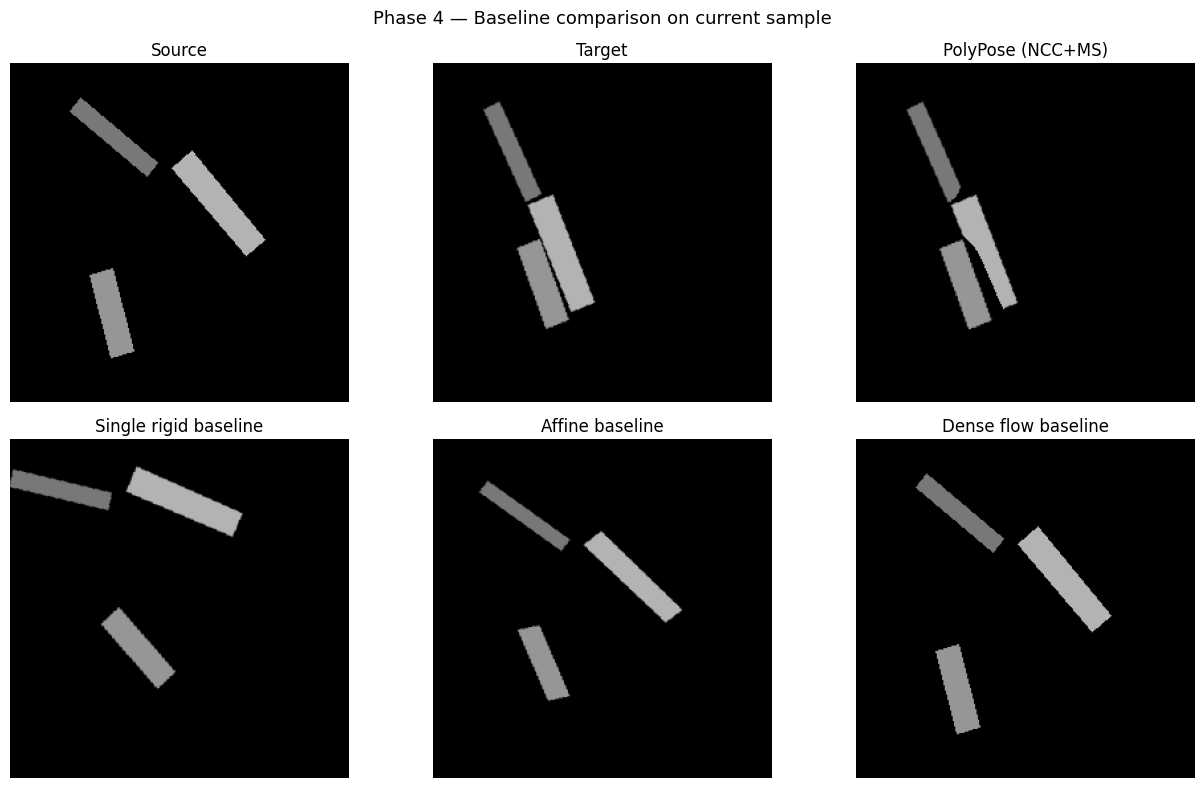

In [18]:
# %% ---------- Phase 4: Baseline methods + quantitative comparison ----------
# Baselines implemented here:
#   1) Single rigid transform (ECC, Euclidean motion)
#   2) Affine transform (ECC, Affine motion)
#   3) Dense displacement field (Farneback optical flow)
# Compared against: PolyPose NCC + multi-scale output from above.

def _to_float01(img):
    arr = np.asarray(img, dtype=np.float32)
    if arr.max() > 1.0:
        arr = arr / 255.0
    return np.clip(arr, 0.0, 1.0)


def mse_metric(a, b):
    a = _to_float01(a); b = _to_float01(b)
    return float(np.mean((a - b) ** 2))


def ssim_global(a, b):
    # Global SSIM (single-window variant) for lightweight comparison.
    a = _to_float01(a); b = _to_float01(b)
    mu_a, mu_b = a.mean(), b.mean()
    var_a, var_b = a.var(), b.var()
    cov_ab = ((a - mu_a) * (b - mu_b)).mean()
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    num = (2 * mu_a * mu_b + c1) * (2 * cov_ab + c2)
    den = (mu_a ** 2 + mu_b ** 2 + c1) * (var_a + var_b + c2)
    return float(num / (den + 1e-12))


def deformation_smoothness(inv_field):
    # Average gradient magnitude of inverse mapping (target -> source).
    fx = inv_field[..., 0].astype(np.float32)
    fy = inv_field[..., 1].astype(np.float32)
    dfx_dx = np.gradient(fx, axis=1)
    dfx_dy = np.gradient(fx, axis=0)
    dfy_dx = np.gradient(fy, axis=1)
    dfy_dy = np.gradient(fy, axis=0)
    grad_mag = np.sqrt(dfx_dx**2 + dfx_dy**2 + dfy_dx**2 + dfy_dy**2)
    return float(np.mean(grad_mag))


def jacobian_stats(inv_field):
    fx = inv_field[..., 0].astype(np.float32)
    fy = inv_field[..., 1].astype(np.float32)
    dfx_dx = np.gradient(fx, axis=1)
    dfx_dy = np.gradient(fx, axis=0)
    dfy_dx = np.gradient(fy, axis=1)
    dfy_dy = np.gradient(fy, axis=0)
    det_j = dfx_dx * dfy_dy - dfx_dy * dfy_dx
    fold_pct = 100.0 * float(np.mean(det_j <= 0.0))
    return fold_pct, float(np.mean(det_j))


def _inv_field_from_affine(warp_2x3, h, w):
    # Build inverse map y->x from an estimated source->target affine warp.
    winv = cv2.invertAffineTransform(warp_2x3.astype(np.float32))
    gx, gy = np.meshgrid(np.arange(w, dtype=np.float32), np.arange(h, dtype=np.float32))
    mx = winv[0, 0] * gx + winv[0, 1] * gy + winv[0, 2]
    my = winv[1, 0] * gx + winv[1, 1] * gy + winv[1, 2]
    return np.stack([mx, my], axis=-1)


def run_ecc_baseline(source, target, motion_type):
    src = _to_float01(source).astype(np.float32)
    tgt = _to_float01(target).astype(np.float32)
    h, w = src.shape
    warp = np.eye(2, 3, dtype=np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 500, 1e-6)

    try:
        _, warp = cv2.findTransformECC(tgt, src, warp, motion_type, criteria, None, 1)
    except cv2.error:
        # Fall back to identity if ECC fails to converge.
        warp = np.eye(2, 3, dtype=np.float32)

    warped = cv2.warpAffine(
        src, warp, (w, h),
        flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP,
        borderMode=cv2.BORDER_CONSTANT, borderValue=0.0
    )
    inv_field = _inv_field_from_affine(warp, h, w)
    return warped, inv_field


def run_dense_flow_baseline(source, target):
    # Estimate inverse field directly as flow from target->source.
    src = _to_float01(source).astype(np.float32)
    tgt = _to_float01(target).astype(np.float32)
    h, w = src.shape

    flow_t2s = cv2.calcOpticalFlowFarneback(
        tgt, src, None,
        pyr_scale=0.5, levels=3, winsize=25, iterations=5,
        poly_n=7, poly_sigma=1.5, flags=0
    )

    gx, gy = np.meshgrid(np.arange(w, dtype=np.float32), np.arange(h, dtype=np.float32))
    mx = gx + flow_t2s[..., 0]
    my = gy + flow_t2s[..., 1]
    warped = cv2.remap(src, mx, my, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    inv_field = np.stack([mx, my], axis=-1)
    return warped, inv_field


def evaluate_registration(method, warped, target, inv_field):
    fold_pct, mean_det = jacobian_stats(inv_field)
    return {
        'method': method,
        'mse': mse_metric(warped, target),
        'ssim': ssim_global(warped, target),
        'smoothness': deformation_smoothness(inv_field),
        'fold_pct': fold_pct,
        'mean_detJ': mean_det,
    }


# ---- Run baselines on current sample ----
rigid_warped, rigid_inv = run_ecc_baseline(source, target, cv2.MOTION_EUCLIDEAN)
affine_warped, affine_inv = run_ecc_baseline(source, target, cv2.MOTION_AFFINE)
dense_warped, dense_inv = run_dense_flow_baseline(source, target)

poly_inv = invert_field(phi_trained, n_iter=20)
poly_warped = _to_float01(warped_ncc_ms)

baseline_results = [
    evaluate_registration('PolyPose (NCC+MS)', poly_warped, target, poly_inv),
    evaluate_registration('Single rigid (ECC)', rigid_warped, target, rigid_inv),
    evaluate_registration('Affine (ECC)', affine_warped, target, affine_inv),
    evaluate_registration('Dense flow (Farneback)', dense_warped, target, dense_inv),
]

print('=' * 95)
print(f"{'Method':<28} {'MSE':>10} {'SSIM':>10} {'Smooth':>12} {'Fold%':>10} {'mean detJ':>12}")
print('-' * 95)
for r in baseline_results:
    print(f"{r['method']:<28} {r['mse']:>10.5f} {r['ssim']:>10.4f} {r['smoothness']:>12.4f} {r['fold_pct']:>10.3f} {r['mean_detJ']:>12.4f}")
print('=' * 95)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
panels = [
    (source, 'Source'),
    (target, 'Target'),
    (poly_warped, 'PolyPose (NCC+MS)'),
    (rigid_warped, 'Single rigid baseline'),
    (affine_warped, 'Affine baseline'),
    (dense_warped, 'Dense flow baseline'),
]
for ax, (img, ttl) in zip(axes.flatten(), panels):
    ax.imshow(_to_float01(img), cmap='gray', vmin=0, vmax=1)
    ax.set_title(ttl); ax.axis('off')
plt.suptitle('Phase 4 — Baseline comparison on current sample', fontsize=13)
plt.tight_layout(); plt.show()

## Phase 5: Ablation Studies

Two ablations validate the most critical design choices:

1. **Annealed weights** — starts with nearly uniform weights (high temperature T=30) so every part always receives gradient signal. Temperature halves each stage, cooling to sharp distance-based weights by the final stage. Addresses the local-minimum problem where weakly-moving parts get ignored early in training.
2. **No weight normalization** — removes the partition-of-unity constraint $\sum_k w_k = 1$, testing whether normalization is necessary for accuracy and diffeomorphic regularity.

In [19]:
# %% ---------- Phase 5: Ablation experiments ----------
import types


def _make_annealed_weights(masks_np, temp, base_dists, masses):
    """Softmax weights at a given temperature over negative distances.
    High T → nearly uniform (every part gets gradient).
    Low T → sharp distance-based (correct polyrigid structure).
    """
    logits = -base_dists / (temp + 1e-6)
    logits -= logits.max(axis=0, keepdims=True)
    Wf = np.exp(logits) * masses[:, None, None]
    Wf /= (Wf.sum(axis=0, keepdims=True) + 1e-12)
    return Wf.astype(np.float32)


def train_multiscale_annealed(self,
                               schedule=((200, 8.0), (200, 4.0), (300, 2.0), (400, 0.5)),
                               temp_schedule=None,
                               print_every=50):
    if temp_schedule is None:
        n_stages = len(schedule)
        temp_schedule = [30.0 / (2 ** s) for s in range(n_stages)]

    orig_source = self.source
    orig_target = self.target

    K = self.W.shape[0]
    H, W_px = self.W.shape[1], self.W.shape[2]
    masks_np = []
    for k in range(K):
        w_np = self.W[k].cpu().numpy()
        masks_np.append((w_np == self.W.cpu().numpy().max(axis=0)).astype(np.uint8) * 255)

    base_dists = np.zeros((K, H, W_px), dtype=np.float32)
    masses     = np.zeros(K, dtype=np.float32)
    for k in range(K):
        base_dists[k] = distance_transform_edt(masks_np[k] == 0).astype(np.float32)
        masses[k]     = float((masks_np[k] > 0).sum())
    masses /= (masses.sum() + 1e-12)

    print(f"Annealed training  device={self.device}")
    print(f"Schedule: {list(schedule)}")
    print(f"Temp schedule: {[f'{t:.1f}' for t in temp_schedule]}\n")

    it_total = 0
    for stage, ((n_iter, sigma), temp) in enumerate(zip(schedule, temp_schedule)):
        W_annealed = _make_annealed_weights(masks_np, temp, base_dists, masses)
        self.W = torch.from_numpy(W_annealed).float().to(self.device)

        lr_scale = 0.5 ** stage
        self.optimizer = torch.optim.Adam([
            {'params': [self.omega], 'lr': self.lr_rotation    * lr_scale},
            {'params': [self.v],     'lr': self.lr_translation * lr_scale},
        ])

        print(f"  stage {stage+1}/{len(schedule)}: sigma={sigma:.1f}  temp={temp:.1f}")
        self.source = _blur(orig_source, sigma)
        self.target = _blur(orig_target, sigma)

        for _ in range(n_iter):
            self.optimizer.zero_grad()
            warped, _ = self.forward()
            loss = self.compute_loss(warped)
            loss.backward()
            self.optimizer.step()
            self.history['loss'].append(loss.item())
            self.history['params'].append(self._snapshot_params())
            it_total += 1
            if it_total == 1 or it_total % print_every == 0:
                print(f"    iter {it_total:4d}  loss={loss.item():+.6f}")

    self.source = orig_source
    self.target = orig_target
    with torch.no_grad():
        warped, phi = self.forward()
    print(f"\nfinal xi_k:\n{self._snapshot_params()}")
    return warped.detach().cpu().numpy(), phi.detach().cpu().numpy()


PolyPoseTrainer.train_multiscale_annealed = train_multiscale_annealed


_PHASE5_SCHEDULE = ((100, 8.0), (100, 4.0), (150, 2.0), (150, 0.5))
_PHASE5_SCHEDULE_ANN = ((300, 8.0), (200, 4.0), (300, 2.0), (400, 0.5))


def run_ablation(source_in, target_in, masks_in, normalize_weights=True, use_annealed=False):
    trainer = PolyPoseTrainer(
        source_in, target_in, masks_in,
        lr_rotation=1e-2, lr_translation=1.0, n_invert_iter=10,
    )
    if not normalize_weights:
        K = len(masks_in)
        H, W_px = masks_in[0].shape
        dists  = np.zeros((K, H, W_px), dtype=np.float32)
        masses = np.zeros(K, dtype=np.float32)
        for k, m in enumerate(masks_in):
            dists[k]  = distance_transform_edt(m == 0).astype(np.float32)
            masses[k] = float(m.sum())
        masses /= (masses.sum() + 1e-12)
        Wf = masses[:, None, None] / (1.0 + dists ** 2)
        trainer.W = torch.from_numpy(Wf.astype(np.float32)).float().to(trainer.device)

    if use_annealed:
        warped, phi = trainer.train_multiscale_annealed(
            schedule=_PHASE5_SCHEDULE, print_every=999999
        )
    else:
        warped, phi = trainer.train_multiscale(
            schedule=_PHASE5_SCHEDULE_ANN, print_every=999999
        )

    inv_field = invert_field(phi, n_iter=20)
    metrics   = evaluate_registration('tmp', warped, target_in, inv_field)
    metrics['final_loss'] = float(trainer.history['loss'][-1])
    return metrics, warped


ablations = [
    ('Default (normalized weights)', True,  False),
    ('Annealed weights',             True,  True),
    ('No weight normalization',      False, False),
]

ablation_rows  = []
ablation_warps = []
for name, norm_on, annealed in ablations:
    print(f"\n{'='*60}\n  Running: {name}\n{'='*60}")
    met, warped_ab = run_ablation(source, target, masks,
                                  normalize_weights=norm_on,
                                  use_annealed=annealed)
    ablation_rows.append({'setting': name, 'mse': met['mse'],
                          'ssim': met['ssim'], 'smooth': met['smoothness'],
                          'fold': met['fold_pct']})
    ablation_warps.append(warped_ab)

print('\n' + '=' * 80)
print(f"{'Variant':<35} {'MSE':>10} {'SSIM':>10} {'Smooth':>12} {'Fold%':>10}")
print('-' * 80)
for r in ablation_rows:
    print(f"{r['setting']:<35} {r['mse']:>10.5f} {r['ssim']:>10.4f} {r['smooth']:>12.4f} {r['fold']:>10.3f}")
print('=' * 80)



  Running: Default (normalized weights)
Multi-scale training   loss=MNCC   device=cpu
Schedule (iters, sigma):  [(300, 8.0), (200, 4.0), (300, 2.0), (400, 0.5)]

── stage 1/4:  σ =  8.0,  300 iters  lr_rot=0.0100  lr_trans=1.000
    iter    1  σ= 8.0   loss = -0.096546
── stage 2/4:  σ =  4.0,  200 iters  lr_rot=0.0050  lr_trans=0.500
── stage 3/4:  σ =  2.0,  300 iters  lr_rot=0.0025  lr_trans=0.250
── stage 4/4:  σ =  0.5,  400 iters  lr_rot=0.0013  lr_trans=0.125  (finest)

final ξ_k:
[[  0.4488969    9.342765   -19.910147  ]
 [ -0.09820084 -11.603368   -14.0851555 ]
 [  0.3194457  -20.266222    -3.115618  ]]

  Running: Annealed weights
Annealed training  device=cpu
Schedule: [(100, 8.0), (100, 4.0), (150, 2.0), (150, 0.5)]
Temp schedule: ['30.0', '15.0', '7.5', '3.8']

  stage 1/4: sigma=8.0  temp=30.0
    iter    1  loss=-0.144486
  stage 2/4: sigma=4.0  temp=15.0
  stage 3/4: sigma=2.0  temp=7.5
  stage 4/4: sigma=0.5  temp=3.8

final xi_k:
[[  0.36303723 -11.31351     66.26562

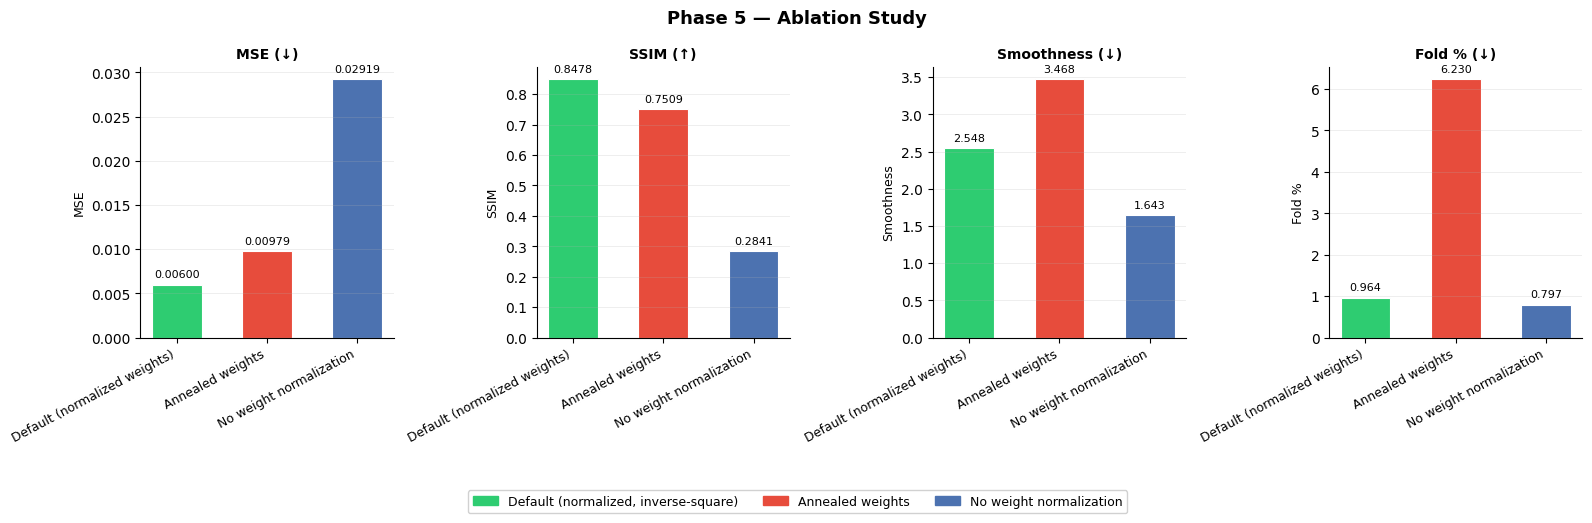

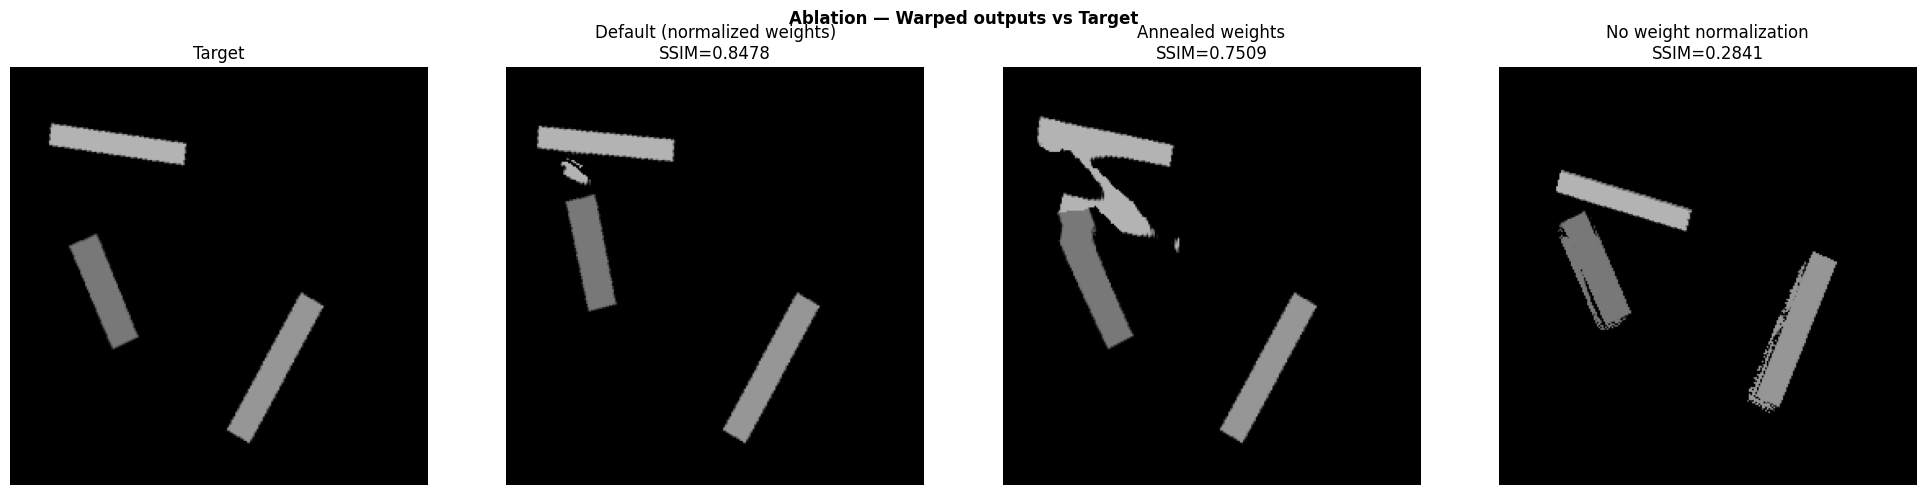

In [122]:
# %% ---------- Phase 5: Ablation chart ----------
import matplotlib.patches as mpatches

metrics_list  = ['mse',      'ssim',   'smooth',       'fold']
titles        = ['MSE (↓)',  'SSIM (↑)', 'Smoothness (↓)', 'Fold % (↓)']
ylabels       = ['MSE',      'SSIM',   'Smoothness',   'Fold %']
fmts          = ['{:.5f}',  '{:.4f}', '{:.3f}',       '{:.3f}']
higher_better = [False,      True,     False,          False]
bar_colors    = ['#2ECC71',  '#E74C3C', '#4C72B0']   # default=green, annealed=red, no-norm=blue

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Phase 5 — Ablation Study', fontsize=13, fontweight='bold')

names = [r['setting'] for r in ablation_rows]
for ax, metric, title, ylabel, fmt, hb in zip(
        axes, metrics_list, titles, ylabels, fmts, higher_better):
    vals = [r[metric] for r in ablation_rows]
    bars = ax.bar(range(len(names)), vals, color=bar_colors,
                  edgecolor='white', linewidth=0.8, width=0.55)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=28, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.02,
                fmt.format(v), ha='center', va='bottom', fontsize=8)

patches = [
    mpatches.Patch(color='#2ECC71', label='Default (normalized, inverse-square)'),
    mpatches.Patch(color='#E74C3C', label='Annealed weights'),
    mpatches.Patch(color='#4C72B0', label='No weight normalization'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.9)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('../../outputs/fig08_ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Visual comparison: warped outputs ────────────────────────────────────────
fig2, axes2 = plt.subplots(1, len(ablations) + 1, figsize=(5 * (len(ablations) + 1), 5))
axes2[0].imshow(_to_float01(target), cmap='gray', vmin=0, vmax=1)
axes2[0].set_title('Target'); axes2[0].axis('off')
for ax, warped_ab, row in zip(axes2[1:], ablation_warps, ablation_rows):
    ax.imshow(_to_float01(warped_ab), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"{row['setting']}\nSSIM={row['ssim']:.4f}")
    ax.axis('off')
plt.suptitle('Ablation — Warped outputs vs Target', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Checklist

- Synthetic dataset generator
- SE(2) log/exp implementation and validation
- Polyrigid field construction and visualization
- Differentiable optimization pipeline
- Baseline methods implemented and compared
- Robustness + ablation table
- Final report + presentation